In [2]:
import pandas as pd

In [3]:
emp = pd.read_excel(r'E:\vs-code-prakash\data\Rawdata.xlsx')

In [4]:
emp.head()

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience#$,34 years,Mumbai,5^00#0,2+
1,Teddy^,Testing,45' yr,Bangalore,10%%000,<3
2,Uma#r,Dataanalyst^^#,NaN,NaN,1$5%000,4> yrs
3,Jane,Ana^^lytics,NaN,Hyderbad,2000^0,NaN
4,Uttam*,Statistics,67-yr,NaN,30000-,5+ year


In [5]:
emp.shape

(6, 6)

In [6]:
emp.columns

Index(['Name', 'Domain', 'Age', 'Location', 'Salary', 'Exp'], dtype='str')

In [8]:
emp.tail()

,Name,Domain,Age,Location,Salary,Exp
1,Teddy^,Testing,45' yr,Bangalore,10%%000,<3
2,Uma#r,Dataanalyst^^#,NaN,NaN,1$5%000,4> yrs
3,Jane,Ana^^lytics,NaN,Hyderbad,2000^0,NaN
4,Uttam*,Statistics,67-yr,NaN,30000-,5+ year
5,Kim,NLP,55yr,Delhi,6000^$0,10+


In [9]:
emp.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Name      6 non-null      str  
 1   Domain    6 non-null      str  
 2   Age       4 non-null      str  
 3   Location  4 non-null      str  
 4   Salary    6 non-null      str  
 5   Exp       5 non-null      str  
dtypes: str(6)
memory usage: 619.0 bytes


In [10]:
emp.Domain

0     Datascience#$
1           Testing
2    Dataanalyst^^#
3       Ana^^lytics
4        Statistics
5               NLP
Name: Domain, dtype: str

In [11]:
emp.isnull()

,Name,Domain,Age,Location,Salary,Exp
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,True,True,False,False
3,False,False,True,False,False,True
4,False,False,False,True,False,False
5,False,False,False,False,False,False


In [12]:
emp.isnull().sum()

Name        0
Domain      0
Age         2
Location    2
Salary      0
Exp         1
dtype: int64

In [ ]:
emp['Name'] # here we have lot of noise characters ^,.*! blabla

0      Mike
1    Teddy^
2     Uma#r
3      Jane
4    Uttam*
5       Kim
Name: Name, dtype: str

In [14]:
emp['Name'] = emp.Name.str.replace(r'\W','',regex=True) # \W non word characters replace with empty

In [15]:
emp.Name

0     Mike
1    Teddy
2     Umar
3     Jane
4    Uttam
5      Kim
Name: Name, dtype: str

In [16]:
emp.Domain = emp.Domain.str.replace(r'\W','',regex=True)

In [17]:
emp.Domain

0    Datascience
1        Testing
2    Dataanalyst
3      Analytics
4     Statistics
5            NLP
Name: Domain, dtype: str

In [18]:
emp.Age = emp.Age.str.replace(r'\W','',regex=True)

In [19]:
emp.Age

0    34years
1       45yr
2        NaN
3        NaN
4       67yr
5       55yr
Name: Age, dtype: str

In [20]:
emp.Age = emp.Age.str.extract('(\\d+)')  # r(r'(\\d+)')

In [21]:
emp.Age

0     34
1     45
2    NaN
3    NaN
4     67
5     55
Name: Age, dtype: str

In [22]:
emp

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5^00#0,2+
1,Teddy,Testing,45,Bangalore,10%%000,<3
2,Umar,Dataanalyst,NaN,NaN,1$5%000,4> yrs
3,Jane,Analytics,NaN,Hyderbad,2000^0,NaN
4,Uttam,Statistics,67,NaN,30000-,5+ year
5,Kim,NLP,55,Delhi,6000^$0,10+


In [23]:
emp.Location = emp.Location.str.replace(r'\W','',regex=True)  # Location is not needed but safe side there my be any empty spaces to avoid those

In [24]:
emp.Salary = emp.Salary.str.replace(r'\W','',regex=True) 

In [25]:
emp

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2+
1,Teddy,Testing,45,Bangalore,10000,<3
2,Umar,Dataanalyst,NaN,NaN,15000,4> yrs
3,Jane,Analytics,NaN,Hyderbad,20000,NaN
4,Uttam,Statistics,67,NaN,30000,5+ year
5,Kim,NLP,55,Delhi,60000,10+


In [26]:
emp.Exp = emp.Exp.str.extract('(\\d+)')  # r(r'(\\d+)')

In [27]:
emp

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,NaN,NaN,15000,4
3,Jane,Analytics,NaN,Hyderbad,20000,NaN
4,Uttam,Statistics,67,NaN,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [28]:
clean_data = emp.copy()

In [29]:
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,NaN,NaN,15000,4
3,Jane,Analytics,NaN,Hyderbad,20000,NaN
4,Uttam,Statistics,67,NaN,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [30]:
clean_data.isnull().sum()

Name        0
Domain      0
Age         2
Location    2
Salary      0
Exp         1
dtype: int64

# EDA TECHNIQUE LETS APPLY 

### missing value treatment

In [31]:
import numpy as np

In [32]:
clean_data['Age'] = clean_data['Age'].fillna(np.mean(pd.to_numeric(clean_data['Age'])))

In [33]:
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50.25,NaN,15000,4
3,Jane,Analytics,50.25,Hyderbad,20000,NaN
4,Uttam,Statistics,67,NaN,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [41]:
clean_data['Exp'] = clean_data['Exp'].fillna(np.mean(pd.to_numeric(clean_data['Exp'])))

In [42]:
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50.25,NaN,15000,4
3,Jane,Analytics,50.25,Hyderbad,20000,4.8
4,Uttam,Statistics,67,NaN,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [43]:
clean_data['Location'].isnull().sum()

np.int64(2)

In [44]:
clean_data['Location'] = clean_data['Location'].fillna(clean_data['Location'].mode()[0])

In [45]:
clean_data['Location'] 

0       Mumbai
1    Bangalore
2    Bangalore
3     Hyderbad
4    Bangalore
5        Delhi
Name: Location, dtype: str

In [46]:
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50.25,Bangalore,15000,4
3,Jane,Analytics,50.25,Hyderbad,20000,4.8
4,Uttam,Statistics,67,Bangalore,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [47]:
emp.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Name      6 non-null      str  
 1   Domain    6 non-null      str  
 2   Age       4 non-null      str  
 3   Location  4 non-null      str  
 4   Salary    6 non-null      str  
 5   Exp       5 non-null      str  
dtypes: str(6)
memory usage: 573.0 bytes


In [48]:
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      6 non-null      str   
 1   Domain    6 non-null      str   
 2   Age       6 non-null      object
 3   Location  6 non-null      str   
 4   Salary    6 non-null      str   
 5   Exp       6 non-null      object
dtypes: object(2), str(4)
memory usage: 574.0+ bytes


In [49]:
clean_data.Age = clean_data.Age.astype(int)

In [50]:
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      6 non-null      str   
 1   Domain    6 non-null      str   
 2   Age       6 non-null      int64 
 3   Location  6 non-null      str   
 4   Salary    6 non-null      str   
 5   Exp       6 non-null      object
dtypes: int64(1), object(1), str(4)
memory usage: 574.0+ bytes


In [51]:
clean_data.Salary = clean_data.Salary.astype(int)
clean_data.Exp = clean_data.Exp.astype(int)

In [52]:
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Name      6 non-null      str  
 1   Domain    6 non-null      str  
 2   Age       6 non-null      int64
 3   Location  6 non-null      str  
 4   Salary    6 non-null      int64
 5   Exp       6 non-null      int64
dtypes: int64(3), str(3)
memory usage: 544.0 bytes


In [53]:
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50,Bangalore,15000,4
3,Jane,Analytics,50,Hyderbad,20000,4
4,Uttam,Statistics,67,Bangalore,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [54]:
clean_data.Name = clean_data.Name.astype('category')
clean_data.Domain = clean_data.Domain.astype('category')
clean_data.Location = clean_data.Location.astype('category')

In [55]:
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Name      6 non-null      category
 1   Domain    6 non-null      category
 2   Age       6 non-null      int64   
 3   Location  6 non-null      category
 4   Salary    6 non-null      int64   
 5   Exp       6 non-null      int64   
dtypes: category(3), int64(3)
memory usage: 529.0 bytes


In [57]:
clean_data.to_csv('clean_data.csv')

In [58]:
import os
os.getcwd()  # from the os give the current working directory

'e:\\vs-code-prakash\\fsds-genai-agenticai-ws\\6.EDA'

In [59]:
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50,Bangalore,15000,4
3,Jane,Analytics,50,Hyderbad,20000,4
4,Uttam,Statistics,67,Bangalore,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

# univariate analysis i.e plot graph with single variable

In [61]:
clean_data['Salary']

0     5000
1    10000
2    15000
3    20000
4    30000
5    60000
Name: Salary, dtype: int64

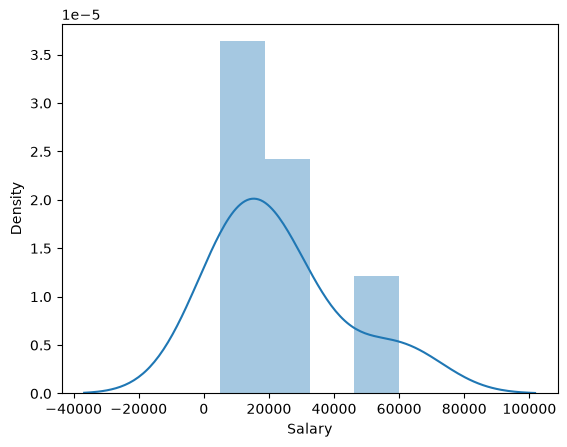

In [ ]:
vis1 = sns.distplot(clean_data['Salary']) # univariate analysis i.e plot graph with single variable
# vis1.plot()

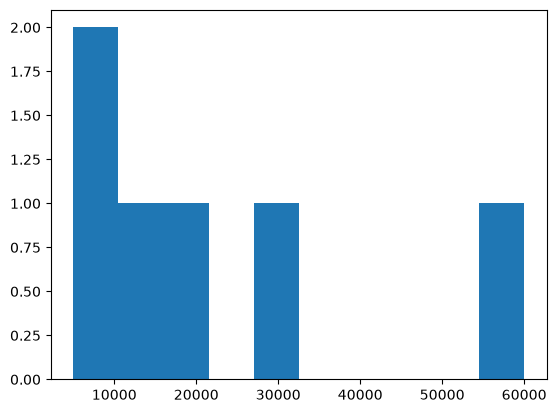

In [ ]:
vis2 = plt.hist(clean_data['Salary'])  # here we can see one outlier i.e one employee got 60000 salary is far away from others

# bivariate analysis and when exp increases salary also increases, this is positive correlation

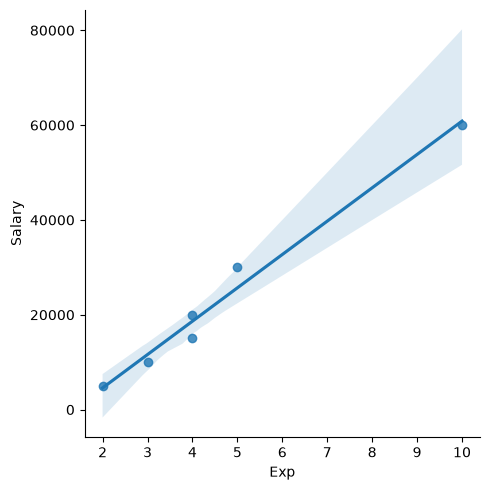

In [67]:
vis3 = sns.lmplot(data=clean_data, x='Exp',y='Salary') 
# bivariate analysis and when exp increases salary also increases, this is positive correlation

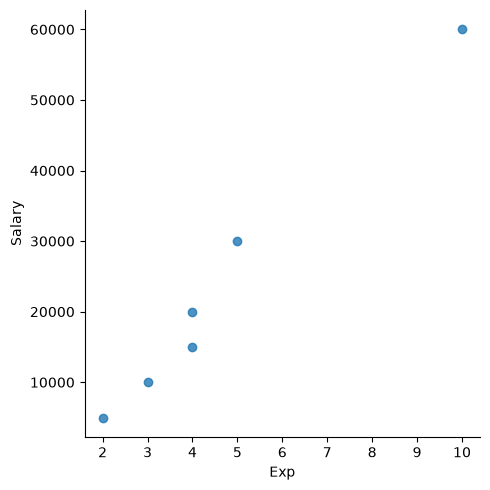

In [66]:
vis4 = sns.lmplot(data=clean_data, x='Exp',y='Salary',fit_reg=False) # bivariate analysis

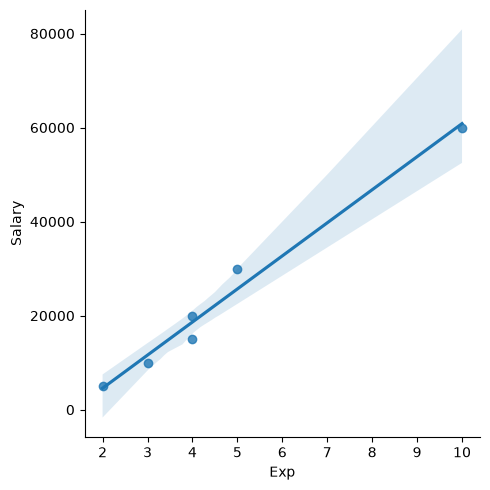

In [69]:
vis5 = sns.lmplot(data=clean_data, x='Exp',y='Salary',fit_reg=True) # bivariate analysis

# variable identification -- split the dataset 
# train_test_split 

In [70]:
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50,Bangalore,15000,4
3,Jane,Analytics,50,Hyderbad,20000,4
4,Uttam,Statistics,67,Bangalore,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [71]:
X_iv = clean_data[['Name','Domain','Age','Location','Exp']]

In [72]:
X_iv

,Name,Domain,Age,Location,Exp
0,Mike,Datascience,34,Mumbai,2
1,Teddy,Testing,45,Bangalore,3
2,Umar,Dataanalyst,50,Bangalore,4
3,Jane,Analytics,50,Hyderbad,4
4,Uttam,Statistics,67,Bangalore,5
5,Kim,NLP,55,Delhi,10


In [73]:
y_dv = clean_data['Salary']

In [74]:
y_dv

0     5000
1    10000
2    15000
3    20000
4    30000
5    60000
Name: Salary, dtype: int64

In [75]:
emp

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,NaN,NaN,15000,4
3,Jane,Analytics,NaN,Hyderbad,20000,NaN
4,Uttam,Statistics,67,NaN,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [76]:
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50,Bangalore,15000,4
3,Jane,Analytics,50,Hyderbad,20000,4
4,Uttam,Statistics,67,Bangalore,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [77]:
X_iv

,Name,Domain,Age,Location,Exp
0,Mike,Datascience,34,Mumbai,2
1,Teddy,Testing,45,Bangalore,3
2,Umar,Dataanalyst,50,Bangalore,4
3,Jane,Analytics,50,Hyderbad,4
4,Uttam,Statistics,67,Bangalore,5
5,Kim,NLP,55,Delhi,10


In [78]:
y_dv

0     5000
1    10000
2    15000
3    20000
4    30000
5    60000
Name: Salary, dtype: int64

# variable creations and transformations

In [ ]:
imputation = pd.get_dummies(clean_data)

In [80]:
imputation

,Age,Salary,Exp,Name_Jane,Name_Kim,Name_Mike,Name_Teddy,Name_Umar,Name_Uttam,Domain_Analytics,Domain_Dataanalyst,Domain_Datascience,Domain_NLP,Domain_Statistics,Domain_Testing,Location_Bangalore,Location_Delhi,Location_Hyderbad,Location_Mumbai
0,34,5000,2,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True
1,45,10000,3,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False
2,50,15000,4,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False
3,50,20000,4,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False
4,67,30000,5,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False
5,55,60000,10,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False


In [81]:
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50,Bangalore,15000,4
3,Jane,Analytics,50,Hyderbad,20000,4
4,Uttam,Statistics,67,Bangalore,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [82]:
len(clean_data)

6

In [83]:
imputation.columns

Index(['Age', 'Salary', 'Exp', 'Name_Jane', 'Name_Kim', 'Name_Mike',
       'Name_Teddy', 'Name_Umar', 'Name_Uttam', 'Domain_Analytics',
       'Domain_Dataanalyst', 'Domain_Datascience', 'Domain_NLP',
       'Domain_Statistics', 'Domain_Testing', 'Location_Bangalore',
       'Location_Delhi', 'Location_Hyderbad', 'Location_Mumbai'],
      dtype='str')

In [84]:
len(imputation.columns)

19

* raw data with lot of regex, missing, uncleandata
* regex, clean 
* fill missing numerical & cateigroica
* clean_dataset ( data cleaning) 3 month - 5mont
* outlier treatement, univati, bivariate, corelation 
* split the data into x_i.v & y_dv
*  impute cateogrica data to numerical 
* eda part complete 

# Next step 
* we splitn x_iv -- x_train, x_test
* we split y_dv -- y_train, y_test
* build the ml model with x_train & y_train 
